# Japan — F-Score grid study: k ∈ {20, 25, 30} × N ∈ {1000, 2000, 5000}

The Japan half of the reviewer-suggested 3 × 3 × 2 grid (basket sizes ×
random-sample sizes × two markets). All nine cells run in this one notebook;
each writes `results/grid/japan_k{k}_mc{N}_*.csv` and its four figures
exactly as before, so the per-cell outputs are unchanged.

Signals come from the team's FS_clean statements, scored by this repository's
own signal code (`fscore.signal.piotroski`, unit-tested, beginning-of-year
asset scaling on both sides of every delta); prices from the cached Yahoo
data. Formations are July 1 of **2012–2024** (13 chained holding years, each a
full twelve months) using score year T−1 — one conservative timing rule for
both markets, over identical calendar time so the two are comparable. July
2024 is the last formation whose complete year finishes inside the sample.
Covariances are estimated on 36 months of daily returns ending the day before
formation. Note the panel resolves to *currently listed* symbols, so the
universe is survivorship-tilted — disclosed as a data limitation. The value
control falls back to the universe in years before B/M coverage begins
(flagged in the diagnostics).

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW and
plain universe minimum-variance controls; a dollar-neutral long-short book
(long top-k scores, short bottom-k, charged both legs' trading costs plus a
stock-borrow fee) wherever shorting is available — Vietnam runs long-only, so
`fscore_LS` is simply absent there; denoised (not detoned) GMV; primary
measure fixed in advance = the GROSS Sharpe ratio (rf = 0), with turnover and
net-of-cost figures reported separately; and the synergy test
D = Sharpe(GMV) − Sharpe(EW) computed per basket. All figures are saved at
dpi = 300.

**On seeding.** Every cell calls `run_grid(..., seed=42)`, and every random
draw inside it is made by a locally constructed
`np.random.default_rng(seed + year)` — the global NumPy generator is never
touched. A cell's result is therefore a function of (market, k, N, seed)
alone, which is what lets all nine share a process without affecting each
other.

In [1]:
import sys, pathlib, time
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.score_panel import build_score_panel
from fscore.data.team_scores import sectors_from_scores
from fscore.grid import run_grid
from fscore.plotting import setup_plots, save_fig

setup_plots()          # study-wide figure defaults; every saved chart is 300 dpi
MARKET = "japan"
KS, MCS = [20, 25, 30], [1000, 2000, 5000]
YEARS = list(range(2012, 2025))
FIG = ROOT / "results" / "figures"
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)

# Loaded once for all nine cells rather than once per notebook. The source is
# the same one this market's main study uses, so the grid varies k and N
# against the reported dataset instead of a different one.
from fscore.data.bbg_processed import constituents
fund = pd.read_csv(ROOT / "data" / "japan_bbg_fundamentals.csv", parse_dates=["report_date"])
sectors_map = pd.read_csv(ROOT / "data" / "japan_sectors.csv").set_index("ticker")["sector"]
membership = constituents(MARKET, ROOT / "data", YEARS)
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
scores = build_score_panel(fund, [y - 1 for y in YEARS],
                           sectors=sectors_map, membership=membership)
per_year = scores.attrs["per_year"]
sectors = sectors_from_scores(scores)
print(f"{MARKET.upper()}: {scores.ticker.nunique()} tickers, "
      f"{len(scores)} scored firm-years, formations {YEARS[0]}–{YEARS[-1]}")

JAPAN: 111 tickers, 1103 scored firm-years, formations 2012–2024


### 0. Data discarded, and how EQ_OFFER was measured

**Source.** Bloomberg statements from `data/processed/Japan/`, screened to the TPX100 constituent list as of each formation. The universe is ~100 names against the US 500, so the high-B/M subset is roughly 35 and **k = 30 covers 83–91% of it** — the random basket and the F-Score basket then share most of their names, and the comparison has little left to detect. **k = 20 is the interpretable cell for Japan.**

A firm-year enters the study only with a **complete nine-signal F-Score**.
Partial scores are dropped rather than summed over whatever is available —
an incomplete score is not a low score, and keeping them would push those
firms towards the bottom of the ranking and into the short leg.

`no_tm2_assets` counts firm-years scored without a t−2 statement, where the
prior-year ratio falls back to period-end assets; they are scored, not
dropped, and counted so the fallback is visible.

**EQ_OFFER.** The faithful measure is the cash-flow statement's
equity-issuance line; the substitute asks whether the share count rose. They
disagree on 38.2% of US firm-years, and not symmetrically — share counts miss
issuance that buybacks net away, so the substitute scores firms **more
generously** (mean F 6.08 against 5.76, placement flattered by ~14 percentile
points; see `results/eq_offer_sensitivity.csv`). The split below shows which
measure each firm-year actually used, so a market running entirely on the
substitute is read with that bias in mind.

This accounting is a property of the source data, so it is identical across
all nine cells — computed once here, then written under every cell's tag so
each cell's output set stays self-contained.

In [2]:
tot = per_year.sum(numeric_only=True)
print(f"{MARKET.upper()}: {int(tot.scored)} scored firm-years, "
      f"{int(tot.dropped_incomplete_signals)} dropped for incomplete signals "
      f"({100 * tot.dropped_incomplete_signals / (tot.scored + tot.dropped_incomplete_signals):.1f}%)")
print(f"  EQ_OFFER from the cash-flow line : {int(tot.eq_offer_from_cashflow)}")
print(f"  EQ_OFFER from the share count    : {int(tot.eq_offer_from_shares)}")
print(f"  scored without a t-2 statement   : {int(tot.no_tm2_assets)}")
drops_total = per_year.set_index("score_year")
drops_total

JAPAN: 1103 scored firm-years, 195 dropped for incomplete signals (15.0%)
  EQ_OFFER from the cash-flow line : 0
  EQ_OFFER from the share count    : 1103
  scored without a t-2 statement   : 38


,scored,dropped_incomplete_signals,eq_offer_from_cashflow,eq_offer_from_shares,no_tm2_assets
score_year,,,,,
2011,82,18,0,82,8
2012,84,16,0,84,3
2013,84,16,0,84,2
2014,84,16,0,84,3
2015,84,16,0,84,0
2016,85,15,0,85,2
2017,86,14,0,86,2
2018,86,14,0,86,4
2019,84,15,0,84,3


### 1. The sweep

Nine cells, each the full study at one (k, N). Every cell writes the same five
CSVs and four figures it wrote when it was its own notebook. The tables and
charts for a chosen reference cell are shown afterwards; the consolidated grid
follows at the end.

In [3]:
def run_cell(k, n_mc):
    """One grid cell: run, save the five CSVs and four figures, return the
    pieces the consolidated table needs."""
    tag = f"{MARKET}_k{k}_mc{n_mc}"
    study = run_grid(MARKET, scores, prices, sectors, YEARS, k=k, n_mc=n_mc,
                     n_gmv=300, seed=42)
    diag = study.diagnostics()
    summary = study.summary()
    yearly = study.yearly_returns()

    rows = {}
    for pool, label in [("mc_ew", "random (full universe)"),
                        ("mc_nonf_ew", "random (non-F-Score names)")]:
        frame = getattr(study, pool)
        if frame.shape[1]:
            for stat in ["sharpe", "ann_return"]:
                for net in (False, True):
                    basis = "net" if net else "gross"
                    rows[(label, stat, basis)] = study.placement(
                        "fscore_EW", pool, stat, net=net)
    placement = pd.DataFrame(rows).T
    syn = study.synergy()

    # --- figures: same four, same names, same 300 dpi ---
    # left: what the source holds vs what is scored; right: which EQ_OFFER
    # measure each firm-year used, since the substitute is the generous one
    b = per_year.set_index("score_year")
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    axes[0].bar(b.index, b.scored, label="scored", color="tab:blue")
    axes[0].bar(b.index, b.dropped_incomplete_signals, bottom=b.scored,
                label="incomplete nine signals", color="tab:grey")
    axes[0].set_xlabel("score year"); axes[0].set_ylabel("firm-years")
    axes[0].set_title(f"{MARKET.upper()}: held vs scored")
    axes[0].legend(fontsize=7)
    axes[1].bar(b.index, b.eq_offer_from_cashflow, label="cash-flow line",
                color="tab:green")
    axes[1].bar(b.index, b.eq_offer_from_shares, bottom=b.eq_offer_from_cashflow,
                label="share count (generous)", color="tab:orange")
    axes[1].set_xlabel("score year"); axes[1].set_ylabel("firm-years")
    axes[1].set_title(f"{MARKET.upper()}: EQ_OFFER measure used")
    axes[1].legend(fontsize=7)
    plt.tight_layout(); save_fig(f"{tag}_exclusions", directory=FIG); plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    sh = study.mc_metric(study.mc_ew, "sharpe")
    ax.hist(sh, bins=40, alpha=0.75, label=f"{n_mc} random baskets (EW)")
    # the placement index is (pool, statistic, basis); the histogram shows gross
    fs = placement.loc[("random (full universe)", "sharpe", "gross"), "fscore"]
    ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
    ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
    ax.set_title(f"{MARKET.upper()} k={k}: F-Score vs {n_mc} random baskets")
    plt.tight_layout(); save_fig(f"{tag}_mc_hist", directory=FIG); plt.close(fig)

    d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
              - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))],
                                "sharpe")).dropna()
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
    ax.axvline(syn["D_fscore"], color="crimson", lw=2,
               label=f"D(F-Score) = {syn['D_fscore']:.2f}")
    ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets")
    ax.legend(fontsize=8)
    ax.set_title(f"{MARKET.upper()} k={k}: optimisation gain, F-Score basket vs random")
    plt.tight_layout(); save_fig(f"{tag}_synergy_hist", directory=FIG); plt.close(fig)

    nav = (1 + study.daily.fillna(0)).cumprod()
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for c in nav.columns:
        ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
                ls="-" if c.startswith("fscore") else "--", label=c)
    ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
    ax.set_title(f"{MARKET.upper()} k={k}, {n_mc} draws — strategies and controls")
    plt.tight_layout(); save_fig(f"{tag}_nav", directory=FIG); plt.close(fig)

    # --- the same five CSVs, under the same names ---
    drops_total.to_csv(OUT / f"{tag}_exclusions.csv")
    summary.to_csv(OUT / f"{tag}_summary.csv")
    placement.to_csv(OUT / f"{tag}_placement.csv")
    pd.Series(syn).to_frame("value").to_csv(OUT / f"{tag}_synergy.csv")
    yearly.to_csv(OUT / f"{tag}_yearly_returns.csv")
    diag.to_csv(OUT / f"{tag}_diagnostics.csv")
    return study, summary, placement, syn, yearly, diag

In [4]:
cells_out = {}
for k in KS:
    for n_mc in MCS:
        t0 = time.time()
        cells_out[(k, n_mc)] = run_cell(k, n_mc)
        print(f"  k={k:>2} N={n_mc:>4}  done in {time.time()-t0:5.0f}s", flush=True)
print(f"\n{len(cells_out)} cells complete")

  k=20 N=1000  done in   102s


  k=20 N=2000  done in   103s


  k=20 N=5000  done in   126s


  k=25 N=1000  done in   156s


  k=25 N=2000  done in   177s


  k=25 N=5000  done in   210s


  k=30 N=1000  done in   199s


  k=30 N=2000  done in   205s


  k=30 N=5000  done in   236s



9 cells complete


### 2. Reference cell — k = 30, N = 5000

The largest basket and the finest random distribution, shown in full. Every
other cell wrote the same tables and figures to disk; the consolidated grid in
section 4 is where they are compared.

**Primary measure: gross Sharpe; rf = 0.** Gross performance is the
cross-country convention — cost models differ by market and would otherwise
confound the comparison. Turnover is reported beside it, and the net-of-cost
columns follow as a sensitivity.

`nominal_k` is the basket size; `effective_n` is 1/Σw², the number of holdings
the weights actually amount to. They are not the same quantity: an optimised
or sector-capped book concentrates, so its effective N sits below the names
nominally held.

In [5]:
REF = (30, 5000)
study, summary, placement, syn, yearly, diag = cells_out[REF]
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,value_fallback,value_basket_size,n_fscore_high,fscore_mean,fscore_basket_min,tie_break_slots,overlap_random_vs_fscore,overlap_expected,cov_est_days,cov_min_est_days,delisted_in_holding_year,no_price_after_formation,long_short_run,short_leg_max_fscore
year,,,,,,,,,,,,,,,,,,
2012,80,2,80,30,False,30,23,6.775,7.0,7,0.377,0.375,733,366,0,0,True,7.0
2013,82,2,82,30,False,30,7,5.744,6.0,5,0.366,0.366,734,367,0,0,True,5.0
2014,82,2,82,30,False,30,16,6.146,7.0,14,0.365,0.366,736,368,0,0,True,5.0
2015,82,2,82,30,False,30,15,6.488,7.0,15,0.364,0.366,735,367,0,0,True,6.0
2016,82,2,82,30,False,30,15,6.232,7.0,15,0.365,0.366,734,367,0,0,True,6.0
2017,84,1,84,30,False,30,13,5.988,7.0,17,0.358,0.357,735,367,0,0,True,5.0
2018,85,1,85,30,False,30,19,6.459,7.0,11,0.354,0.353,750,375,0,0,True,6.0
2019,84,2,84,30,False,30,13,6.310,7.0,17,0.359,0.357,753,376,0,0,True,6.0
2020,83,1,83,30,False,30,4,5.663,6.0,10,0.361,0.361,751,375,0,0,True,5.0


In [6]:
summary[["ann_return", "ann_vol", "sharpe", "max_drawdown",
         "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.149,0.197,0.756,-0.292,30.0,30.000
fscore_GMV,0.121,0.172,0.706,-0.366,30.0,5.797
fscore_GMVsec,0.132,0.170,0.775,-0.318,30.0,8.063
fscore_high_EW,0.155,0.211,0.733,-0.298,23.0,12.462
value_EW,0.142,0.205,0.692,-0.392,30.0,30.000
universe_EW,0.145,0.192,0.754,-0.301,80.0,83.538
universe_GMV,0.137,0.160,0.852,-0.382,80.0,6.372
fscore_LS,0.012,0.072,0.168,-0.189,60.0,60.000


#### Turnover and the net-of-cost sensitivity (reported separately)

In [7]:
summary[["turnover", "cost_drag", "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.6980,0.0028,0.1460,0.7418
fscore_GMV,0.7423,0.0030,0.1184,0.6885
fscore_GMVsec,0.7458,0.0030,0.1289,0.7574
fscore_high_EW,0.8332,0.0033,0.1514,0.7177
value_EW,0.2375,0.0010,0.1411,0.6875
universe_EW,0.1039,0.0004,0.1444,0.7519
universe_GMV,0.3550,0.0014,0.1353,0.8434
fscore_LS,1.3577,0.0154,-0.0033,-0.0464


### Yearly returns (each formation held July–June, a full twelve months)

In [8]:
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV,fscore_LS
date,,,,,,,,
2012,12.5,3.3,4.1,12.4,14.2,12.7,5.5,4.0
2013,50.6,39.7,41.9,44.3,47.0,51.2,35.8,-1.7
2014,21.2,47.9,45.8,22.4,12.4,14.5,40.1,12.3
2015,8.7,11.8,13.1,11.2,12.2,12.1,11.3,-7.6
2016,4.0,6.6,6.6,8.1,9.0,3.4,2.9,-1.1
2017,19.9,30.4,27.6,18.6,26.0,25.3,40.2,-6.6
2018,-6.3,-22.8,-19.8,-4.4,-13.4,-12.5,-18.3,11.9
2019,18.4,9.7,13.0,21.0,7.6,15.6,5.2,6.8
2020,10.5,-7.2,-4.3,11.4,-9.4,11.3,-7.2,2.5


### 3. Placement vs the random distributions

Reported gross and net of costs. The random control is redrawn every year, so
it carries its own turnover (~1 − k/|universe|) — charging both sides is the
like-for-like comparison; the gross rows show costs are not driving it.

Significance is judged at **one level fixed in advance: 5%** (`significant`
column = p < 0.05). There is no 1% or 10% tier: p = 0.06 is not
significant.

In [9]:
print(f"turnover — F-Score EW {study.strategy_turnover('fscore_EW'):.3f} "
      f"vs random basket {study.mc_turnover():.3f} (one-way, per year)")
placement.round(3)

turnover — F-Score EW 0.698 vs random basket 0.650 (one-way, per year)


percentile p_value significant  \
random (full universe)     sharpe     gross     0.6252  0.3748       False   
                                      net       0.6192  0.3808       False   
                           ann_return gross     0.6642  0.3358       False   
                                      net        0.659   0.341       False   
random (non-F-Score names) sharpe     gross      0.732   0.268       False   
                                      net        0.728   0.272       False   
                           ann_return gross      0.786   0.214       False   
                                      net       0.7784  0.2216       False   

                                            alpha n_draws random_mean  \
random (full universe)     sharpe     gross  0.05    5000    0.738763   
                                      net    0.05    5000    0.725439   
                           ann_return gross  0.05    5000    0.144251   
                                      net    0.05    5000    0.141649   
random (non-F-Score names) sharpe     gross  0.05    5000    0.726452   
                                      net    0.05    5000    0.713101   
                           ann_return gross  0.05    5000    0.141553   
                                      net    0.05    5000    0.138951   

                                            random_std    fscore  basis  
random (full universe)     sharpe     gross   0.056336  0.755938  gross  
                                      net     0.056313  0.741752    net  
                           ann_return gross   0.010878   0.14877  gross  
                                      net     0.010878  0.145978    net  
random (non-F-Score names) sharpe     gross    0.04711  0.755938  gross  
                                      net     0.047088  0.741752    net  
                           ann_return gross    0.00904   0.14877  gross  
                                      net      0.00904  0.145978    net

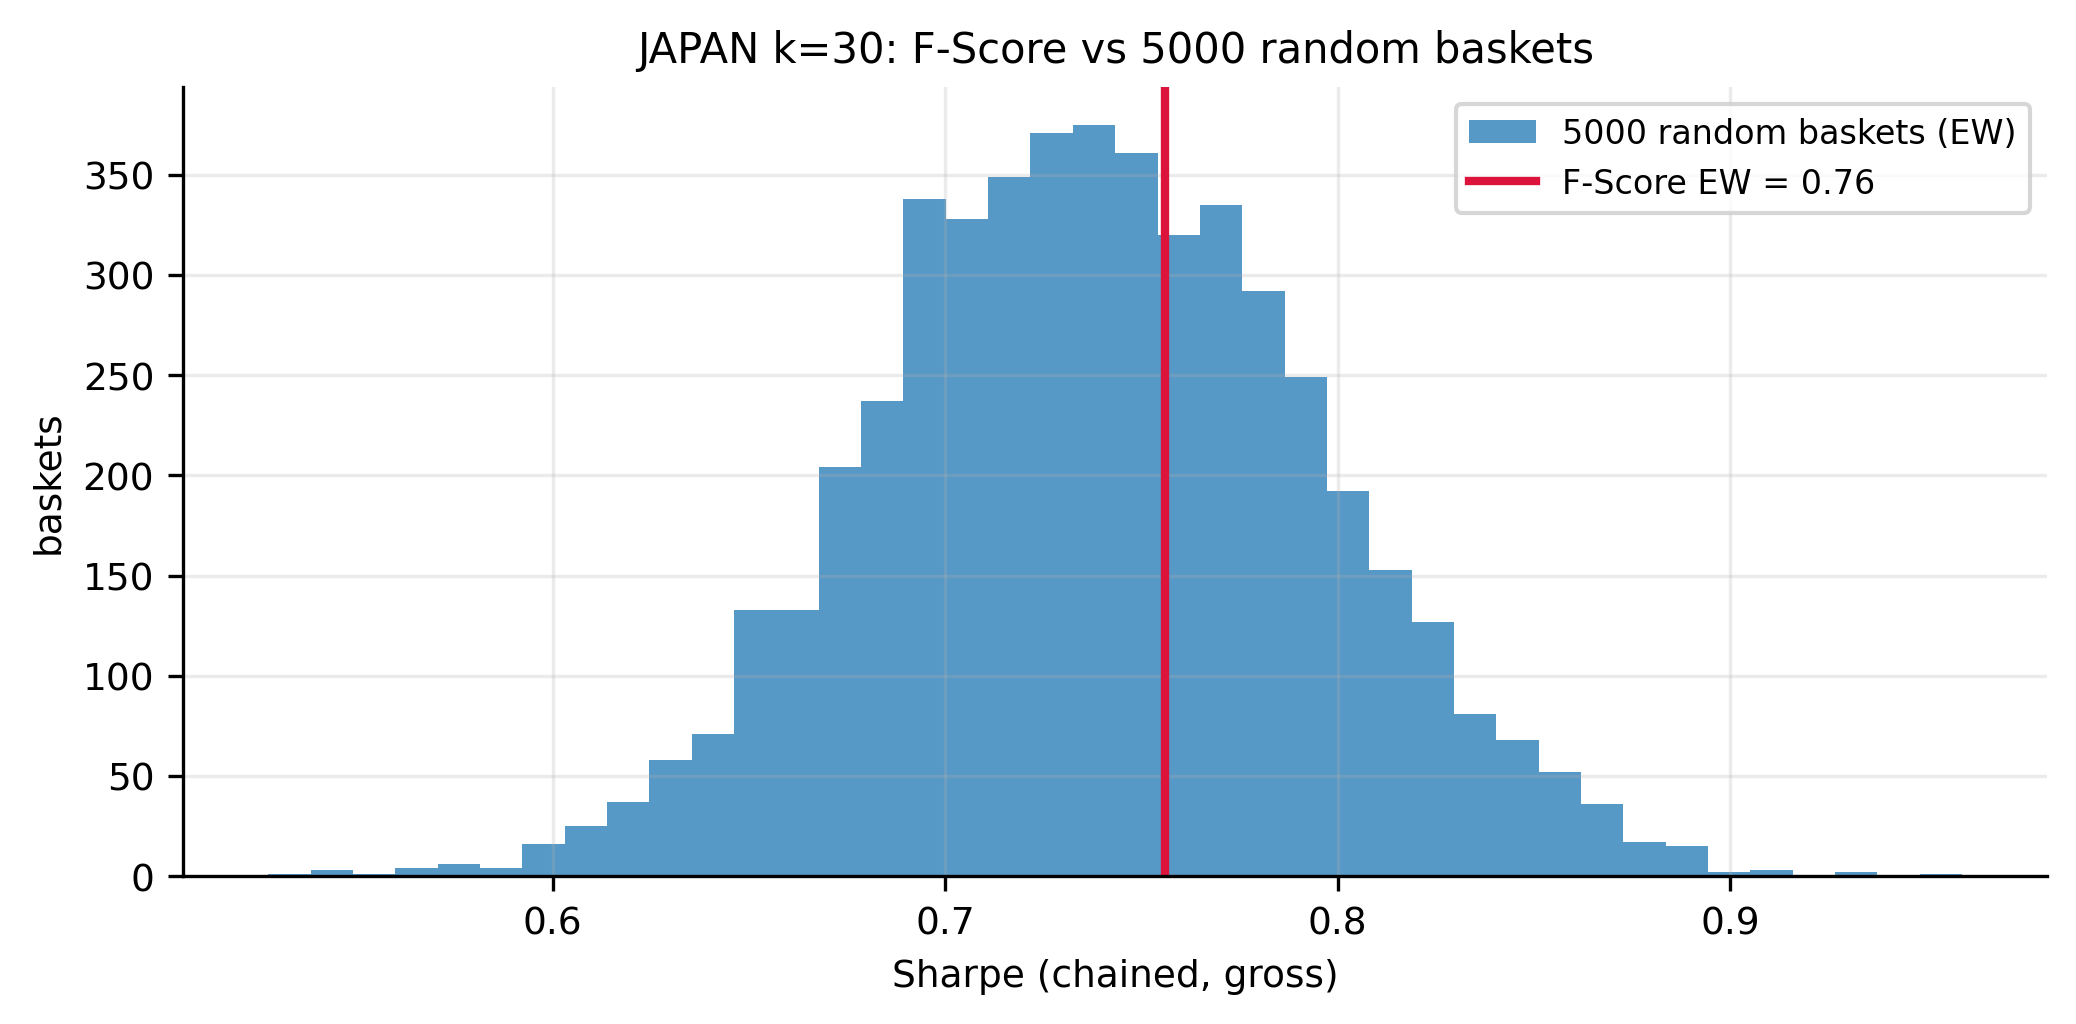

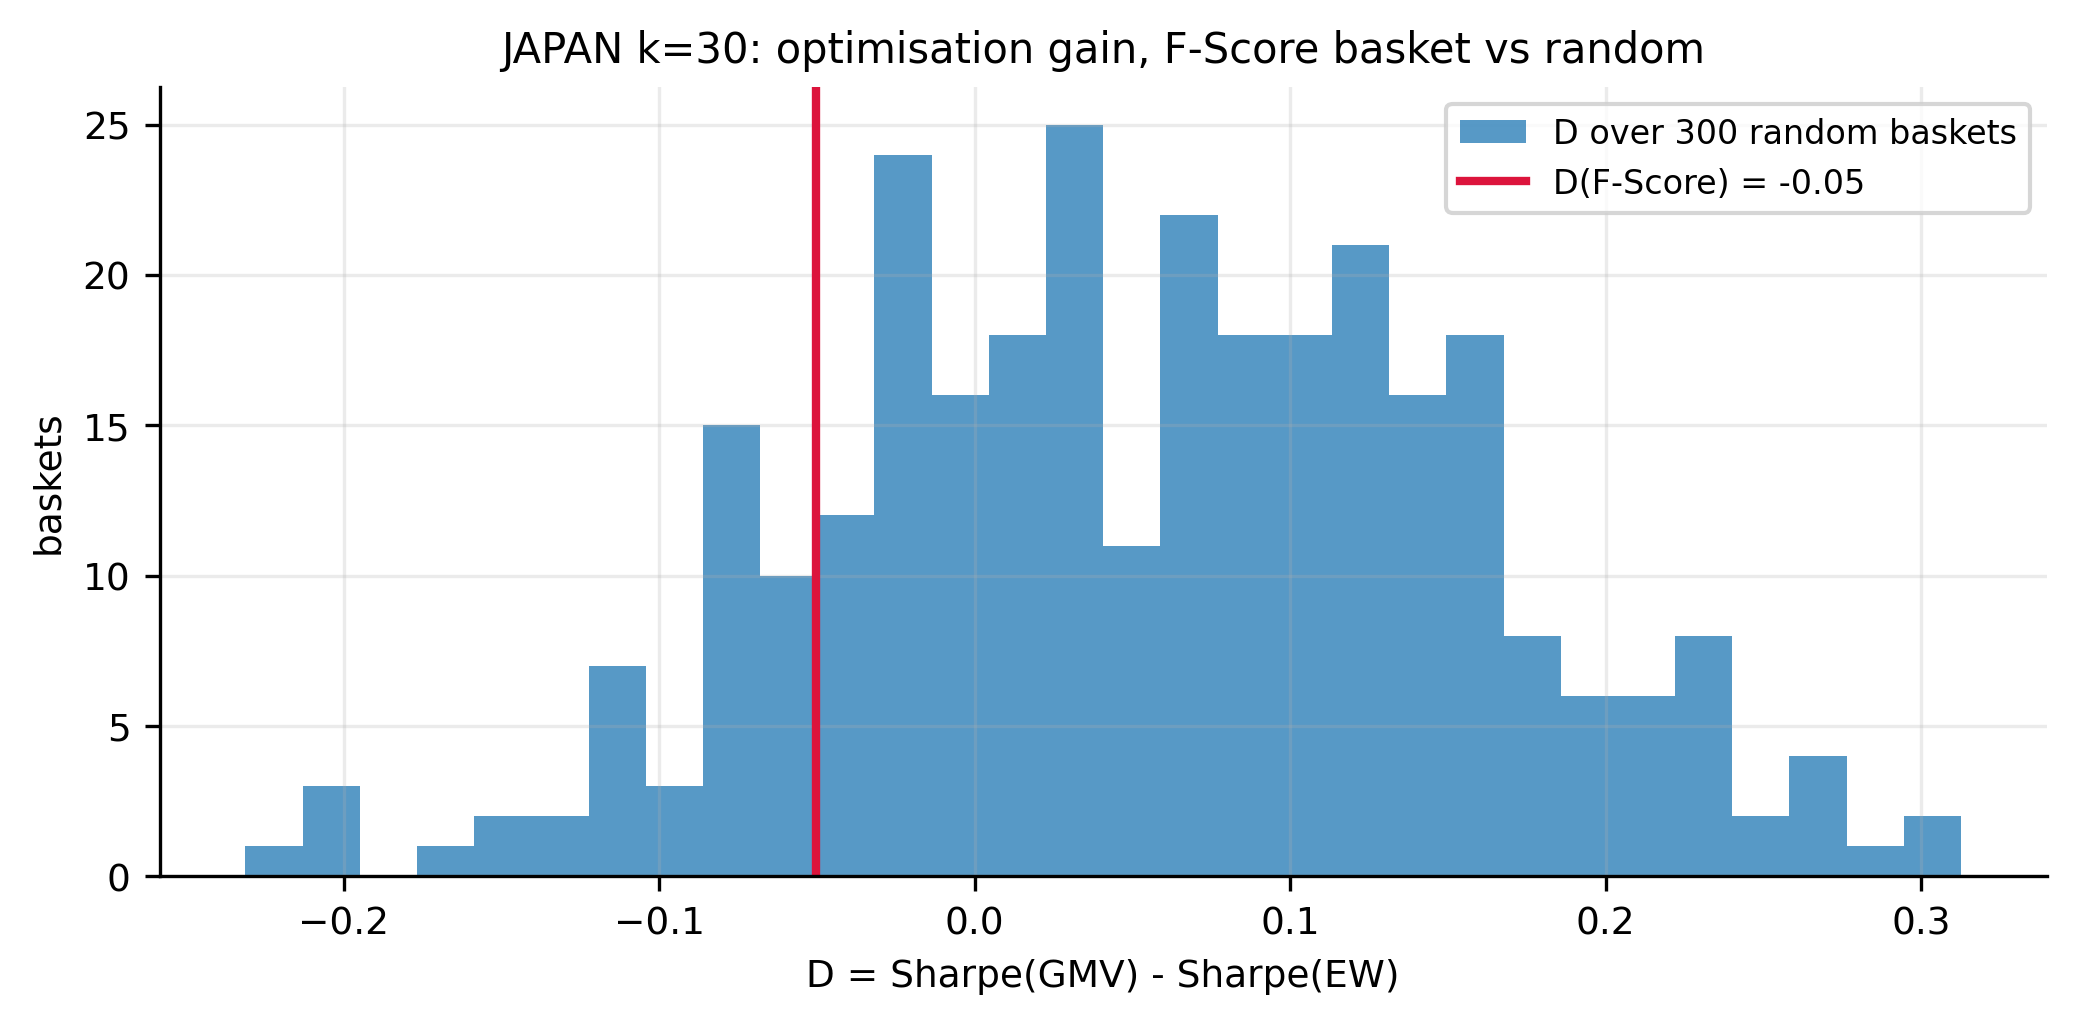

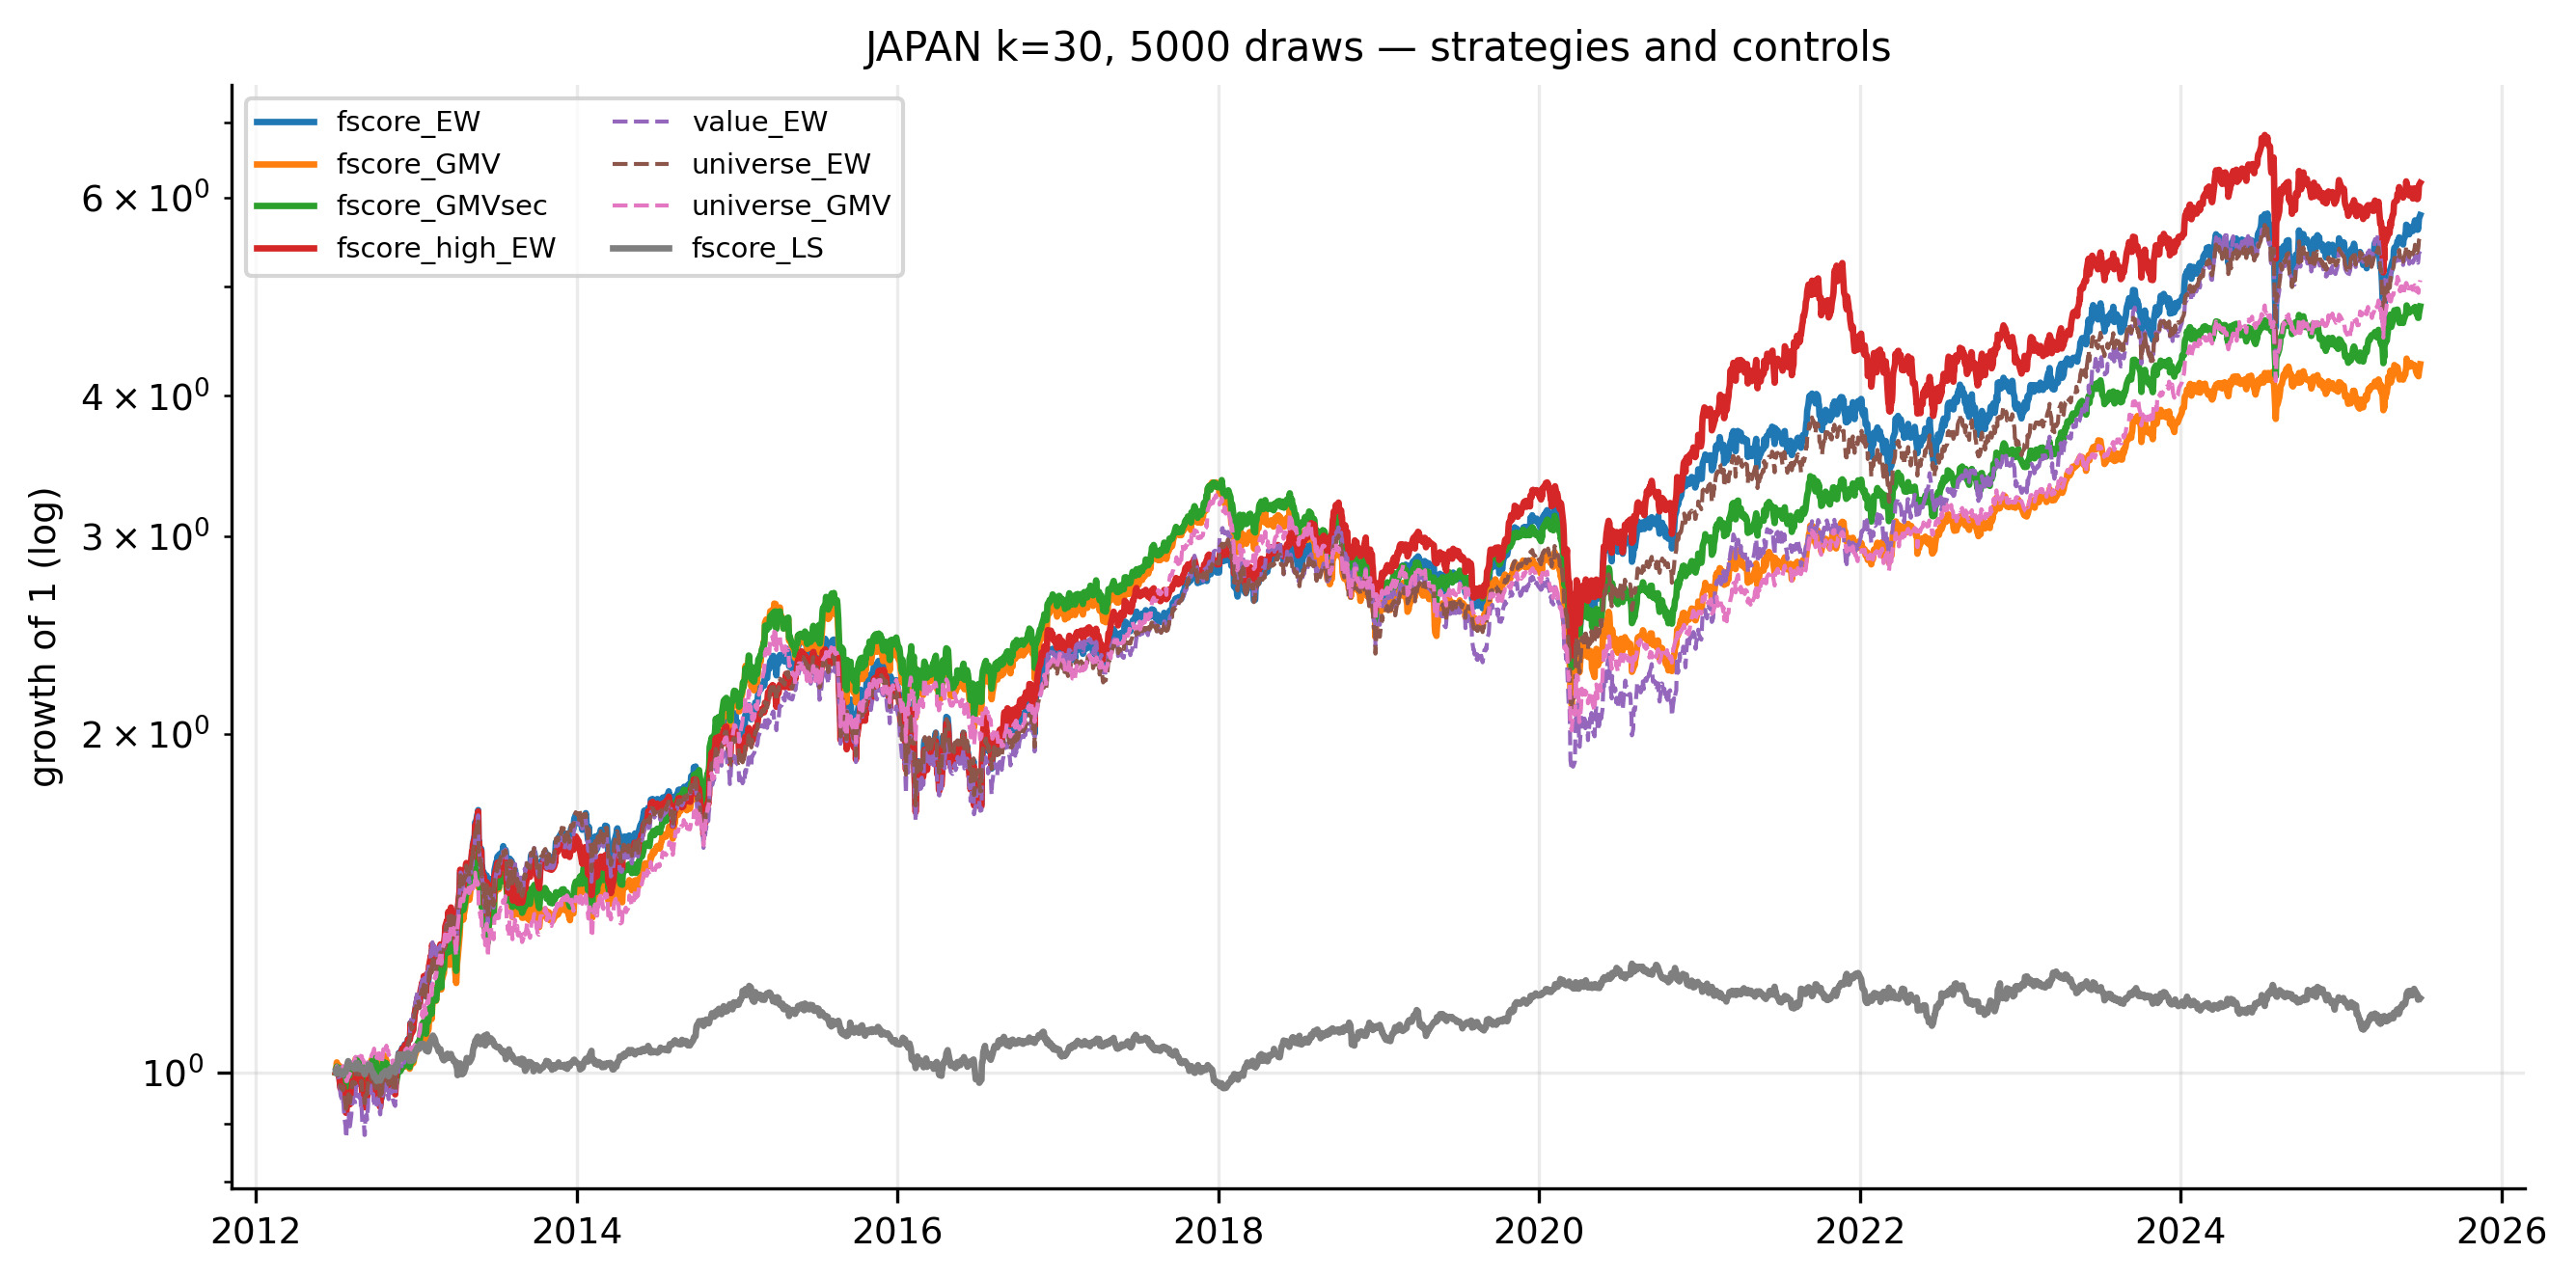

In [10]:
from IPython.display import Image, display
k, n = REF
for suffix in ["mc_hist", "synergy_hist", "nav"]:
    display(Image(filename=str(FIG / f"{MARKET}_k{k}_mc{n}_{suffix}.png"), width=640))

### 4. The consolidated grid

One row per cell. This is what the grid was built to show: whether the
conclusion moves with the basket size or with the number of random draws.

`N` should not move anything but the resolution of the p-value — the same
seed draws the same first 1,000 baskets whether the run asks for 1,000 or
5,000 — so any drift down an `N` block is Monte-Carlo noise, not a finding.
Movement across `k` blocks is the real sensitivity.

In [11]:
rows = []
for (k, n_mc), (st, summ, place, sy, yr, dg) in cells_out.items():
    pl = place.loc[("random (full universe)", "sharpe", "gross")]
    rows.append({
        "mkt": MARKET, "k": k, "N": n_mc,
        "EW": round(float(summ.loc["fscore_EW", "sharpe"]), 4),
        "uniEW": round(float(summ.loc["universe_EW", "sharpe"]), 4)
                 if "universe_EW" in summ.index else np.nan,
        "value": round(float(summ.loc["value_EW", "sharpe"]), 4)
                 if "value_EW" in summ.index else np.nan,
        "to_EW": round(float(summ.loc["fscore_EW", "turnover"]), 4),
        "effN_GMV": round(float(summ.loc["fscore_GMV", "effective_n"]), 4)
                    if "fscore_GMV" in summ.index else np.nan,
        "pct": round(float(pl["percentile"]), 4),
        "p": round(float(pl["p_value"]), 4),
        "sig": bool(pl["significant"]),
        "D": round(float(sy["D_fscore"]), 4),
        "D_p": round(float(sy["p_value"]), 4),
    })
grid = pd.DataFrame(rows).sort_values(["k", "N"]).reset_index(drop=True)
grid.to_csv(OUT / f"{MARKET}_grid_summary.csv", index=False)
grid

,mkt,k,N,EW,uniEW,value,to_EW,effN_GMV,pct,p,sig,D,D_p
0,japan,20,1000,0.7646,0.754,0.6767,0.7513,5.1619,0.6790,0.3210,False,-0.2135,0.9800
1,japan,20,2000,0.7646,0.754,0.6767,0.7513,5.1619,0.6780,0.3220,False,-0.2135,0.9800
2,japan,20,5000,0.7646,0.754,0.6767,0.7513,5.1619,0.6840,0.3160,False,-0.2135,0.9800
3,japan,25,1000,0.7639,0.754,0.7027,0.7066,5.1036,0.6870,0.3130,False,-0.1652,0.9467
4,japan,25,2000,0.7639,0.754,0.7027,0.7066,5.1036,0.6725,0.3275,False,-0.1652,0.9467
5,japan,25,5000,0.7639,0.754,0.7027,0.7066,5.1036,0.6872,0.3128,False,-0.1652,0.9467
6,japan,30,1000,0.7559,0.754,0.6921,0.6980,5.7971,0.6290,0.3710,False,-0.0502,0.8533
7,japan,30,2000,0.7559,0.754,0.6921,0.6980,5.7971,0.6385,0.3615,False,-0.0502,0.8533
8,japan,30,5000,0.7559,0.754,0.6921,0.6980,5.7971,0.6252,0.3748,False,-0.0502,0.8533


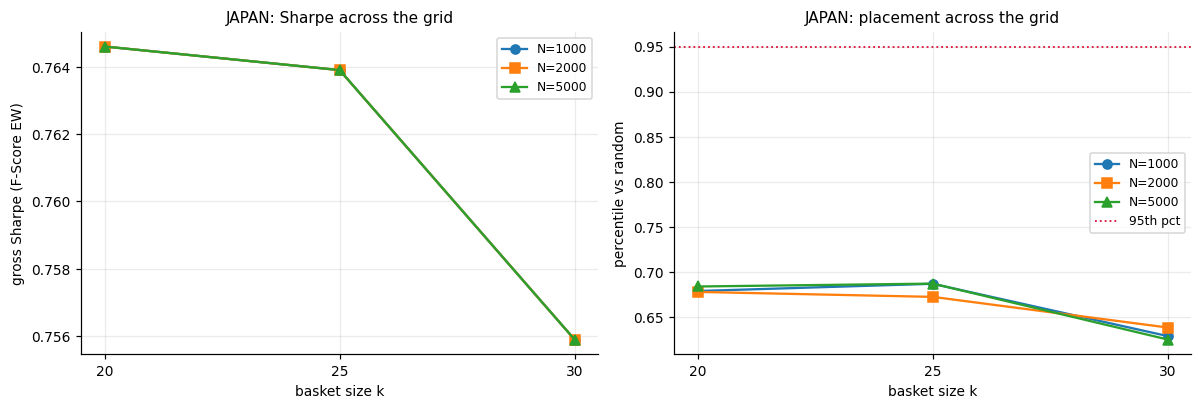

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for n_mc, mark in zip(MCS, ["o", "s", "^"]):
    sub = grid[grid.N == n_mc]
    axes[0].plot(sub.k, sub.EW, mark + "-", label=f"N={n_mc}")
    axes[1].plot(sub.k, sub.pct, mark + "-", label=f"N={n_mc}")
axes[0].set_xlabel("basket size k"); axes[0].set_ylabel("gross Sharpe (F-Score EW)")
axes[0].set_title(f"{MARKET.upper()}: Sharpe across the grid")
axes[1].axhline(0.95, color="crimson", ls=":", lw=1.2, label="95th pct")
axes[1].set_xlabel("basket size k"); axes[1].set_ylabel("percentile vs random")
axes[1].set_title(f"{MARKET.upper()}: placement across the grid")
for a in axes:
    a.set_xticks(KS); a.legend(fontsize=8)
plt.tight_layout(); save_fig(f"{MARKET}_grid_sensitivity", directory=FIG); plt.show()

### 5. Outputs

Each cell's five CSVs and four figures are already on disk under its own
`{market}_k{k}_mc{N}_*` tag — unchanged from when every cell was its own
notebook. This notebook adds one file the eighteen never produced: the
consolidated `{market}_grid_summary.csv` above, which used to be assembled by
hand.

In [13]:
print(f"per-cell outputs : results/grid/{MARKET}_k*_mc*_*.csv  "
      f"({len(cells_out) * 6} files)")
print(f"per-cell figures : results/figures/{MARKET}_k*_mc*_*.png  "
      f"({len(cells_out) * 4} files)")
print(f"consolidated     : results/grid/{MARKET}_grid_summary.csv")

per-cell outputs : results/grid/japan_k*_mc*_*.csv  (54 files)
per-cell figures : results/figures/japan_k*_mc*_*.png  (36 files)
consolidated     : results/grid/japan_grid_summary.csv
